In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
text = "aabb" * 20
chars = sorted(list(set(text)))
stoi = {ch:i for i, ch in enumerate(chars)}
itos = {i:ch for ch, i in stoi.items()}

def encode(s):
    return torch.tensor([stoi[c] for c in s], dtype=torch.long)

def decode(l):
    return ''.join([itos[i] for i in l])

data = encode(text)

vocab_size = len(chars)
block_size = 8

In [3]:
def get_batch():
    x = data[:block_size].unsqueeze(0)
    y = data[1:block_size+1].unsqueeze(0)
    return x, y

In [4]:
class Attention(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.key = nn.Linear(n_embd, n_embd)
        self.query = nn.Linear(n_embd, n_embd)
        self.value = nn.Linear(n_embd, n_embd)
        self.register_buffer("mask", torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x, use_mask=True):
        B, T, C = x.shape  #B: batch size, T: sequence length, C: channel(每个token的向量维度)
        k = self.key(x)
        q = self.query(x)
        attn = q @ k.transpose(-2, -1) / C**0.5

        if use_mask: 
            attn = attn.masked_fill(self.mask[:T, :T] == 0, float('-inf'))

        attn = F.softmax(attn, dim=-1)

        v = self.value(x)
        out = attn @ v

        return out, attn

In [5]:
class TinyGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, 32)
        self.pos_emb = nn.Embedding(block_size, 32)

        self.attn = Attention(32)
        self.lm_head = nn.Linear(32, vocab_size)

    def forward(self, x, y=None, use_mask=True):
        B, T = x.shape

        tok = self.token_emb(x)
        pos = self.pos_emb(torch.arange(T))

        x = tok + pos

        s, attn = self.attn(x, use_mask=use_mask)

        logits = self.lm_head(x)

        loss = None
        if y is not None:
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
        return logits, loss, attn

In [6]:
model = TinyGPT()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
all_losses = []
for step in range(50):
    x, y = get_batch()
    logits, loss, attn = model(x, y, use_mask=True)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    all_losses.append(loss.item())
    print("loss: ", loss.item())

loss:  0.9633694291114807
loss:  0.797569751739502
loss:  0.674635112285614
loss:  0.5923157334327698
loss:  0.5315454602241516
loss:  0.4757991135120392
loss:  0.4198854863643646
loss:  0.36473584175109863
loss:  0.3130461275577545
loss:  0.26715946197509766
loss:  0.22817212343215942
loss:  0.1958562433719635
loss:  0.1691061556339264
loss:  0.14654625952243805
loss:  0.12700620293617249
loss:  0.10973051190376282
loss:  0.09434947371482849
loss:  0.08073297888040543
loss:  0.0688399150967598
loss:  0.05861728638410568
loss:  0.04995966702699661
loss:  0.04271034896373749
loss:  0.036683179438114166
loss:  0.03168646618723869
loss:  0.027541153132915497
loss:  0.02409042790532112
loss:  0.021202942356467247
loss:  0.01877184584736824
loss:  0.016711797565221786
loss:  0.014955032616853714
loss:  0.013448109850287437
loss:  0.012148583307862282
loss:  0.011022625491023064
loss:  0.010042940266430378
loss:  0.009187417104840279
loss:  0.008437768556177616
loss:  0.007778956089168787
lo

/home/minnie/minGPT/.venv/lib/python3.10/site-packages/torch/autograd/graph.py:869: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


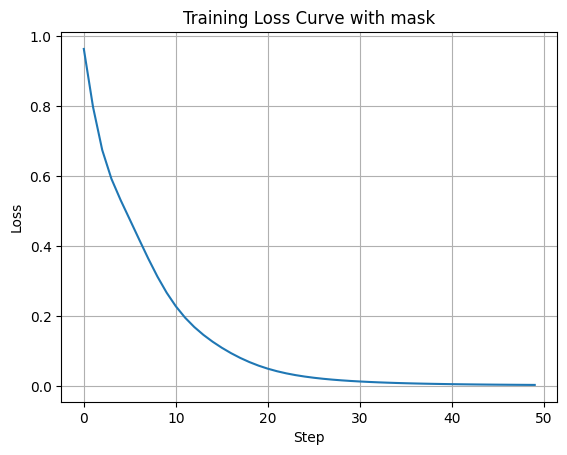

In [7]:
import matplotlib.pyplot as plt

plt.plot(all_losses)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve with mask")
plt.grid(True)
plt.show()

In [8]:
# experiment 2: without mask
model = TinyGPT()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
losses2 = []
for step in range(50):
    x, y = get_batch()
    logits, loss, att = model(x, y, use_mask=False)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses2.append(loss.item())
    print("loss:", loss.item())

loss: 0.560690701007843
loss: 0.4766893982887268
loss: 0.40543532371520996
loss: 0.34183210134506226
loss: 0.2866685092449188
loss: 0.23993825912475586
loss: 0.20032376050949097
loss: 0.1664171814918518
loss: 0.13754801452159882
loss: 0.11337228864431381
loss: 0.09340707957744598
loss: 0.07698637247085571
loss: 0.06345229595899582
loss: 0.05229533463716507
loss: 0.04314413294196129
loss: 0.035694606602191925
loss: 0.029666218906641006
loss: 0.024797853082418442
loss: 0.020858876407146454
loss: 0.01765783503651619
loss: 0.015042800456285477
loss: 0.01289580762386322
loss: 0.01112548727542162
loss: 0.009660298004746437
loss: 0.008443441241979599
loss: 0.007429348770529032
loss: 0.006581027060747147
loss: 0.005868373904377222
loss: 0.005267008673399687
loss: 0.004756981506943703
loss: 0.004322239197790623
loss: 0.003949603531509638
loss: 0.0036285603418946266
loss: 0.003350475337356329
loss: 0.0031083370558917522
loss: 0.0028965426608920097
loss: 0.0027103684842586517
loss: 0.002546003088

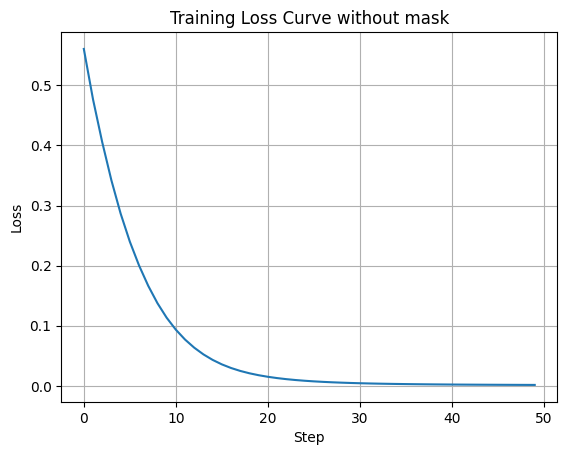

In [9]:
plt.plot(losses2)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss Curve without mask")
plt.grid(True)
plt.show()

In [10]:
# generation task
def generate(model, start, max_new_tokens, use_mask):
    model.eval()
    x = start.clone()
    for _ in range(max_new_tokens):
        x_cond = x[:,-block_size:]
        logits, _, _ = model(x_cond, use_mask=use_mask)
        logits = logits[:, -1, :]
        probs = torch.softmax(logits, dim=1)
        next_token = torch.multinomial(probs, num_samples=1)
        x = torch.cat([x, next_token], dim=1)
    return x

In [11]:
start = data[:10].unsqueeze(0)

In [12]:
# output of training with mask
out = generate(model, start, 50, use_mask=True)
print("with mask:", decode(out[0].tolist()))

with mask: aabbaabbaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa


In [13]:
# output of training without mask
out = generate(model, start, 50, use_mask=True)
print("no mask train → mask generate:", decode(out[0].tolist()))

no mask train → mask generate: aabbaabbaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaa
